Setup

In [16]:
!pip install torchvision -q
import torch
print(f"Pytorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

Pytorch: 2.11.0+cu128, CUDA: True


**Data Loading with Augmentation**

Data Loader applies random transformations (like rotations, flips, crops, or color jittering for images, or noise injection and synonym replacement for text) to each batch dynamically as it's being loaded.

1. Combats overfitting
2. Improves Generalization and Invariance
3. Maximizes Limited Data Efficiently
4. Pipeline Friendly and Memory Efficient


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms.v2 as T

transform_augmented = T.Compose([
    T.ToImage(), T.ToDtype(torch.float32,scale=True),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(32, padding=4),
    T.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    T.Normalize((0.4914,0.4822,0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = T.Compose([
    T.ToImage(), T.ToDtype(torch.float32, scale=True),
    T.Normalize((0.4914,0.4822,0.4465), (0.2470, 0.2435, 0.2616))
])


View Dataset

Total Images: 50000
Class Categories: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image type: <class 'PIL.Image.Image'>
Image Dimensions: (32, 32)
Label Index: 6
Actual class name: frog


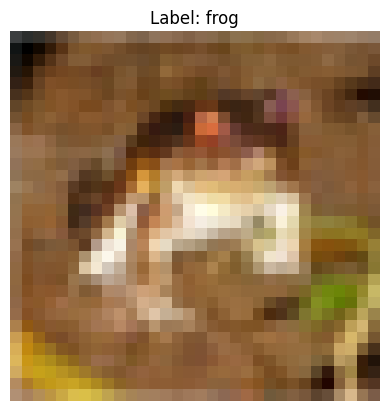

In [18]:
raw_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=None
)

print(f'Total Images: {len(raw_dataset)}')
print(f'Class Categories: {raw_dataset.classes}')

# inspect a sample image
image, label_idx = raw_dataset[0]
print(f"Image type: {type(image)}")
print(f'Image Dimensions: {image.size}')
print(f'Label Index: {label_idx}')
print(f"Actual class name: {raw_dataset.classes[label_idx]}")

# visualize the image
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(f'Label: {raw_dataset.classes[label_idx]}')
plt.axis('off')
plt.show()

cifar10 has 50,000 train and 10,000 test images but no validation split
We'll not use the test set to evaluate after few epochs instead we use test only at the end

Get Validation Set out of Train Set
Use test set only at last (only once)

In [19]:
VAL_SIZE = 5000
train_full = torchvision.datasets.CIFAR10(
    root='./data',train=True, download=True,transform=transform_augmented
)
val_full = torchvision.datasets.CIFAR10(
    root='/data', train=True, download=True, transform=transform_test
)

# seeded, splits must not change in between runs
g = torch.Generator().manual_seed(42)
perm = torch.randperm(len(train_full), generator=g).tolist()

# grabs the last 5,000 indices - val_idx
# grabs the grabs everything else (except last 5000)
train_idx, val_idx = perm[:-VAL_SIZE], perm[-VAL_SIZE:]

train_set = torch.utils.data.Subset(train_full, train_idx)
val_set = torch.utils.data.Subset(val_full, val_idx)
test_set = torchvision.datasets.CIFAR10(root='./data',train=False, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128,shuffle=True,num_workers=2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=128,shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)} Test: {len(test_set)} Validation: {len(val_set)}")
print(f'Classes: {train_full.classes}')



Train: 45000 Test: 10000 Validation: 5000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Data set loaded 50k images(validation set = 5k, train set = 45k) , 10k test

10 classes, 32 * 32 pixel images (so this makes classification difficult)

Batch size - 128


**ResNet Style Architecture**

What are skip connections?

A ResBlock adds the input directly to the output: output = F(x) + x. This "shortcut" lets gradients flow directly through the network, solving the vanishing gradient problem that makes deeper networks hard to train.

In [20]:
class ResBlock(nn.Module):

  def __init__(self, channels):
    super().__init__()
    self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding = 1, bias = False)
    self.bn1 = nn.BatchNorm2d(channels)
    self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding = 1, bias= False)
    self.bn2 = nn.BatchNorm2d(channels)

  def forward(self, x):
    out = torch.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))
    return torch.relu(out + x)

class CIFAR10Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.stem = nn.Sequential(nn.Conv2d(3,64,3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU())
    self.stage1 = ResBlock(64)
    self.pool1 = nn.MaxPool2d(2)
    self.expand2 = nn.Sequential(nn.Conv2d(64,128,3,padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU())
    self.stage2 = ResBlock(128)
    self.pool2 = nn.MaxPool2d(2)
    self.expand3 = nn.Sequential(nn.Conv2d(128,256,3, padding = 1, bias= False), nn.BatchNorm2d(256), nn.ReLU())
    self.stage3 = ResBlock(256)
    self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.2), nn.Linear(256,10))

  def forward(self, x):
    x = self.pool1(self.stage1(self.stem(x)))
    x = self.pool2(self.stage2(self.expand2(x)))
    return self.head(self.stage3(self.expand3(x)))

model = CIFAR10Net()
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 1,923,914


**Training**

1. 50 epochs
2. SGD + momentum
3. cosine annealing
4. mixed precision
5. Gradient clipping
6. Label Smoothing

In [ ]:
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CIFAR10Net().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
use_amp = device.type == 'cuda'

scaler = torch.amp.GradScaler(enabled=use_amp)

EPOCHS, PATIENCE = 50, 10
best_val, best_epoch = 0.0, 0
best_state = copy.deepcopy(model.state_dict())
patience_counter = 0

@torch.no_grad()
def accuracy(model, loader):
  model.eval(),
  correct = total = 0
  for images, labels in loader:
    images, labels = images.to(device), labels.to(device)
    predicted = model(images).max(1)[1]
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
  return 100.0 * correct / total

for epoch in range(EPOCHS):
  model.train()
  running_loss = 0.0
  for images, labels, in train_loader:
    images, labels = images.to(device), labels.to(device)
    with torch.amp.autocast(device_type = device.type, enabled = use_amp):
      loss = criterion(model(images), labels)
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    running_loss += loss.item()
  scheduler.step()

  val_acc = accuracy(model, val_loader)
  if val_acc > best_val:
    best_val, best_epoch = val_acc, epoch + 1
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0
  else:
    patience_counter += 1

  if (epoch + 1) % 5 == 0 or patience_counter >= PATIENCE:
    print(f"Epoch {epoch+1:3d} | Loss: {running_loss/len(train_loader):.4f} "
          f"| Val: {val_acc:.1f}% | Best: {best_val:.1f}% (ep {best_epoch})")

  if patience_counter >= PATIENCE:
    print(f"Early stopping: {PATIENCE} epochs without validation improvement.")
    break

model.load_state_dict(best_state)
print(f"\nRestored the checkpoint validation chose: epoch {best_epoch}, {best_val:.2f}%")

Epoch   5 | Loss: 0.9751 | Val: 77.3% | Best: 77.3% (ep 5)
Epoch  10 | Loss: 0.8521 | Val: 72.1% | Best: 81.7% (ep 6)
